In [1]:
# Parameters
megadescriptor_version = 'T-224'  # 'S-224', 'B-224', 'L-384'
detection = '' # '', _detected', '_detected_manual'
seed = 0
query_ratio = 0.2

In [2]:
# Parameters
megadescriptor_version = "S-224"
detection = ""
query_ratio = 0.2
seed = 0


In [3]:
import torch
import numpy as np
import joblib
import torch.nn as nn
import torch.optim as optim
import random
from collections import defaultdict

In [4]:
np.random.seed(seed)

# Path to new file
data_path = f"saved_models/{megadescriptor_version}/data{detection}.npz"
encoder_path = f"saved_models/{megadescriptor_version}/label_encoder{detection}.pkl"

# Load everything at once
data = np.load(data_path)

embeddings = data["embeddings"]      # shape (N, D)
labels = data["label_ids"]           # integer labels
# original_labels = data["labels"]     # string labels (optional)

print("Embeddings shape:", embeddings.shape)

# Optional: load encoder if you want inverse_transform
encoder = joblib.load(encoder_path)
names = encoder.inverse_transform(labels)

encoder = joblib.load(encoder_path)
id_to_name = dict(enumerate(encoder.classes_))
name_to_id = {v: k for k, v in id_to_name.items()}


Embeddings shape: (319, 768)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


C:\Users\user\AppData\Local\Temp\ipykernel_416\1123045260.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_classes)


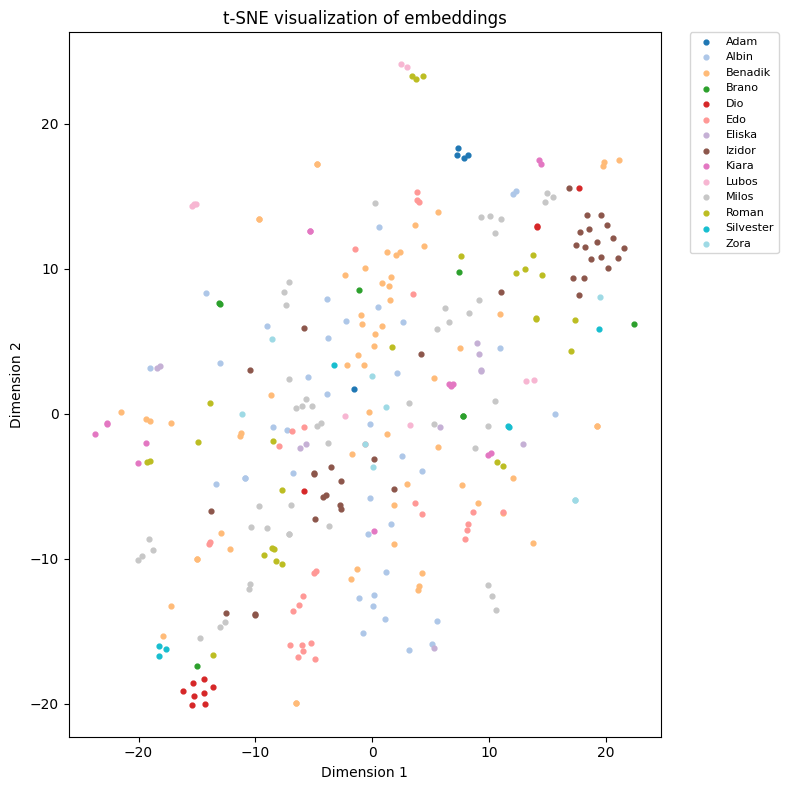

In [6]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

unique_labels = np.unique(labels)
num_classes = len(unique_labels)

# Use high-contrast categorical colormap
cmap = cm.get_cmap('tab20', num_classes)

plt.figure(figsize=(8, 8))

for label in unique_labels:
    mask = labels == label
    
    plt.scatter(
        emb_2d[mask, 0],
        emb_2d[mask, 1],
        s=12,
        color=cmap(label),              # use label as color index
        label=id_to_name[label]         # use class name in legend
    )

plt.title("t-SNE visualization of embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

def evaluate_accuracy_np(embeddings, labels, query_ratio=0.2, seed=0):

    # stratified split (correct + simple)
    db_emb, q_emb, db_labels, q_labels = train_test_split(
        embeddings,
        labels,
        test_size=query_ratio,
        random_state=seed,
        # stratify=labels
    )

    # L2 normalize (required for cosine similarity correctness)
    db_emb = db_emb / np.linalg.norm(db_emb, axis=1, keepdims=True)
    q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)

    # cosine similarity matrix (query → database)
    sim = cosine_similarity(q_emb, db_emb)

    # nearest neighbor in embedding space
    nearest = np.argmax(sim, axis=1)
    predictions = db_labels[nearest]

    accuracy = np.mean(predictions == q_labels)

    print(f"Seed={seed} | Query ratio={query_ratio} | Accuracy={accuracy:.4f}")

    return accuracy

In [8]:

accuracy = evaluate_accuracy_np(embeddings, labels, query_ratio=query_ratio, seed=seed)

Seed=0 | Query ratio=0.2 | Accuracy=0.6562


In [9]:
result = {
    "megadescriptor_version": megadescriptor_version,
    "dataset_version": detection,
    "seed": seed,
    "query_ratio": query_ratio,
    "accuracy": accuracy
}

result

{'megadescriptor_version': 'S-224',
 'dataset_version': '',
 'seed': 0,
 'query_ratio': 0.2,
 'accuracy': 0.65625}